# CAPSTONE PROJEKTAS: Prekybos centro pardavimų ir klientų elgsenos analizė

**Duomenų rinkinys:** Supermarket Sales Dataset
**Tikslas:** Atlikti išsamią duomenų analizę, siekiant suprasti klientų pirkimo įpročius, įvertinti pardavimų tendencijas ir sukurti prognozavimo modelius.

**Analizės etapai:**
1. Duomenų paruošimas ir apžvalga.
2. Aprašomoji analizė (EDA).
3. Pasikliautiniai intervalai.
4. Hipotezių testavimas.
5. Regresinė analizė.
6. Laiko eilučių analizė.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# Nustatome vizualizacijų stilių
sns.set_theme(style="whitegrid")
print("Bibliotekos sėkmingai užkrautos!")

Bibliotekos sėkmingai užkrautos!


In [2]:
# Užkrauname duomenis
df = pd.read_csv('SuperMarketAnalysis1.csv')

# Pažiūrime į pirmas 5 eilutes
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
print(f"Duomenų rinkinys turi {df.shape[0]} eilučių ir {df.shape[1]} stulpelių.")

Duomenų rinkinys turi 1000 eilučių ir 17 stulpelių.


In [4]:
print("--- Duomenų info ---")
print(df.info())

--- Duomenų info ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin pe

In [5]:
print("\n--- Trūkstamos reikšmės ---")
print(df.isnull().sum())


--- Trūkstamos reikšmės ---
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


In [6]:
print("\n--- Aprašomoji statistika (skaitiniai kintamieji) ---")
display(df.describe())


--- Aprašomoji statistika (skaitiniai kintamieji) ---


,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


## 2. Aprašomoji analizė (EDA)
Šioje dalyje analizuosime pagrindinį kintamąjį `Sales` (pardavimus) ir jo ryšius su kitais faktoriais.

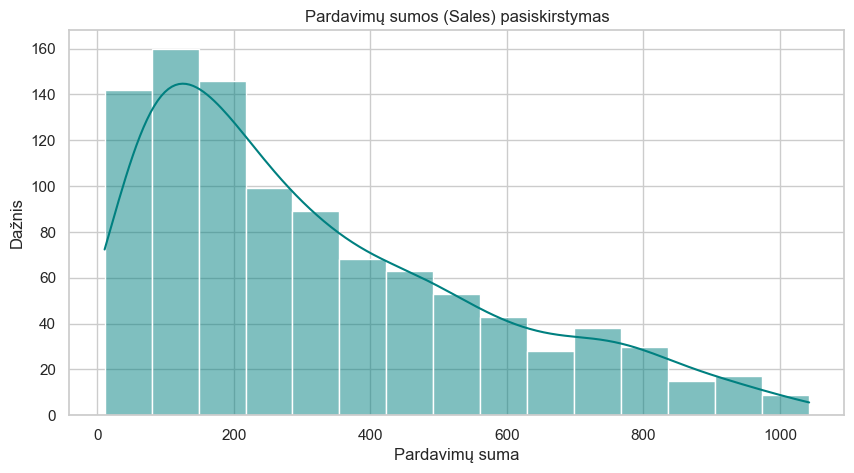

Vidurkis: 322.97
Mediana: 253.85
Standartinis nuokrypis: 245.89


In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales'], kde=True, color='teal')
plt.title('Pardavimų sumos (Sales) pasiskirstymas')
plt.xlabel('Pardavimų suma')
plt.ylabel('Dažnis')
plt.show()

# Papildomai išvedame skaitines reikšmes pagal reikalavimus
print(f"Vidurkis: {df['Sales'].mean():.2f}")
print(f"Mediana: {df['Sales'].median():.2f}")
print(f"Standartinis nuokrypis: {df['Sales'].std():.2f}")

**Įžvalgos:**
Pardavimų sumų (`Sales`) pasiskirstymas yra asimetriškas su teigiama nuokrypa (angl. *positive skew*). Matome, kad dauguma pirkimų yra santykinai nedideli (iki 400), o pirkimų, viršijančių 800, pasitaiko rečiau. Tai rodo, kad prekybos centre dominuoja vidutiniai pirkinių krepšeliai. Regresinei analizei tai gali reikšti, kad paklaidos gali būti nevisiškai normaliosios.

C:\Users\donat\AppData\Local\Temp\ipykernel_20308\2484704777.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='City', y='Sales', data=df, palette='viridis')


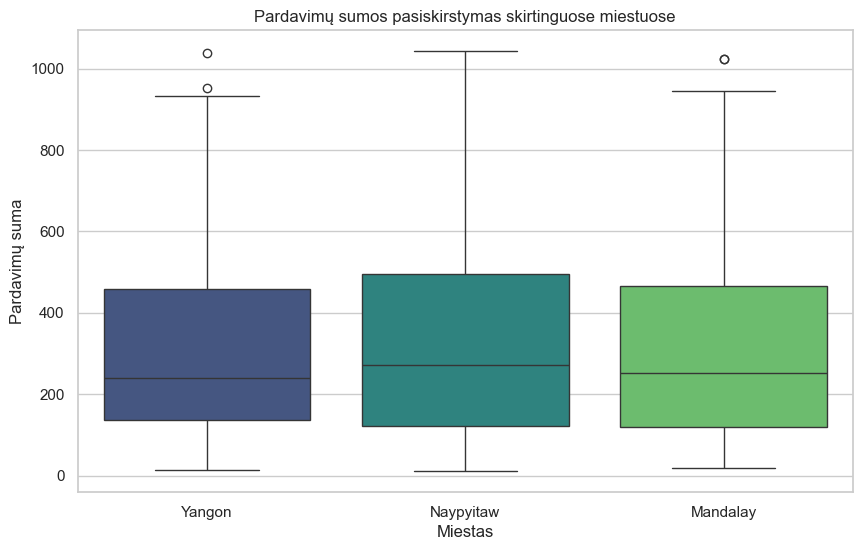

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='City', y='Sales', data=df, palette='viridis')
plt.title('Pardavimų sumos pasiskirstymas skirtinguose miestuose')
plt.xlabel('Miestas')
plt.ylabel('Pardavimų suma')
plt.show()

**Įžvalgos:**
Pardavimų medianos visuose trijuose miestuose (Yangon, Naypyitaw, Mandalay) yra labai panašios. Tai rodo, kad geografinė lokacija nedaro kritinės įtakos vieno pirkimo sumai. Visuose miestuose matome keletą išskirčių (angl. *outliers*) – itin didelių pirkimų, tačiau bendra duomenų sklaida (kvartiliai) išlieka stabili.

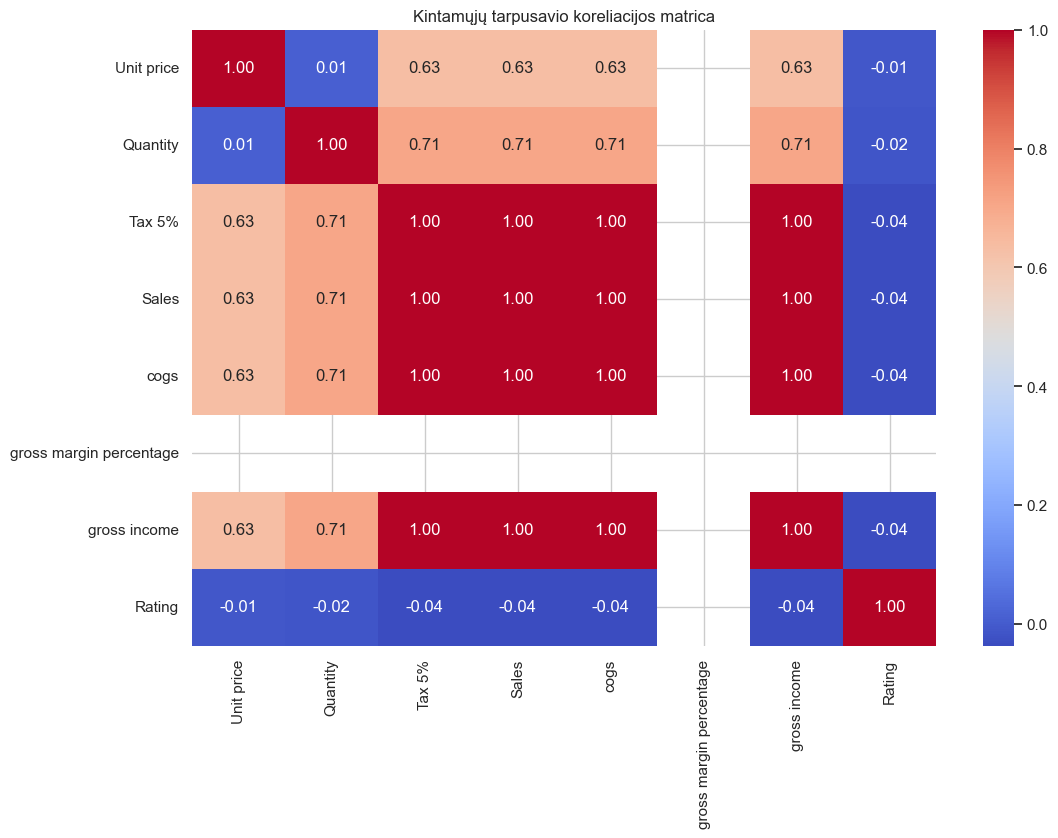

In [9]:
# Tikriname tik skaitinių kintamųjų koreliaciją
plt.figure(figsize=(12, 8))
# Pasirenkame tik skaitinius stulpelius
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Kintamųjų tarpusavio koreliacijos matrica')
plt.show()

**Įžvalgos ir kritinė pastaba:**
Koreliacijų matrica atskleidžia tobulą koreliaciją (1.00) tarp `Sales` ir tokių kintamųjų kaip `Tax 5%`, `cogs` bei `gross income`. 
* **Svarbu:** Tai yra loginė duomenų savybė, nes šie kintamieji apskaičiuojami tiesiogiai iš pardavimo sumos. 
* **Veiksmas:** Siekiant išvengti multikolinearumo problemos (kurią vėliau patikrinsime VIF testu), šie kintamieji nebus įtraukiami į regresijos modelį kaip prognozuojantys požymiai.

## 3. Pasikliautiniai intervalai
Šioje dalyje apskaičiuosime 95 % pasikliautinį intervalą klientų įvertinimų (`Rating`) vidurkiui. Tai padės suprasti, kokiame rėžyje tikėtina rasti tikrąjį visų klientų pasitenkinimo vidurkį.

In [10]:
import scipy.stats as stats

# Duomenys
ratings = df['Rating']
mean_rating = ratings.mean()
std_error = stats.sem(ratings) # Standartinė paklaida
confidence_level = 0.95

# Apskaičiuojame intervalą naudojant t-pasiskirstymą (pagal paskaitų pavyzdžius)
ci = stats.t.interval(confidence_level, len(ratings)-1, loc=mean_rating, scale=std_error)

print(f"Įvertinimų (Rating) vidurkis: {mean_rating:.2f}")
print(f"95% pasikliautinis intervalas: ({ci[0]:.2f}, {ci[1]:.2f})")

Įvertinimų (Rating) vidurkis: 6.97
95% pasikliautinis intervalas: (6.87, 7.08)


**Interpretacija:**
Mes esame 95 % tikri, kad tikrasis visos populiacijos (visų prekybos centro klientų) įvertinimų (`Rating`) vidurkis yra tarp **6,97** ir **7,08**. Kadangi šis intervalas yra siauras, galime daryti išvadą, kad mūsų gautas vidurkis (6,97) yra tikslus ir patikimas įvertis. Verslo požiūriu tai rodo, kad klientų pasitenkinimas yra stabilus ir vidutiniškai siekia apie 7 balus iš 10.

## 4. Hipotezių testavimas
Tikriname, ar lojalumo programa turi įtakos pirkimo sumai. 
**H0:** Vidutinė pirkimo suma tarp 'Member' ir 'Normal' klientų nesiskiria.
**Ha:** Vidutinė pirkimo suma tarp šių grupių skiriasi.

In [11]:
# Atskiriame grupes
member_sales = df[df['Customer type'] == 'Member']['Sales']
normal_sales = df[df['Customer type'] == 'Normal']['Sales']

# Atliekame nepriklausomų imčių t-testą
t_stat, p_val = stats.ttest_ind(member_sales, normal_sales)

print(f"t-statistika: {t_stat:.4f}")
print(f"p-reikšmė: {p_val:.4f}")

# Rezultato interpretacija
alpha = 0.05
if p_val < alpha:
    print("Išvada: Atmetame nulinę hipotezę (H0). Skirtumas tarp grupių yra statistiškai reikšmingas.")
else:
    print("Išvada: Nepavyko atmesti nulinės hipotezės (H0). Statistiškai reikšmingo skirtumo tarp pirkimo sumų nėra.")

t-statistika: 1.8750
p-reikšmė: 0.0611
Išvada: Nepavyko atmesti nulinės hipotezės (H0). Statistiškai reikšmingo skirtumo tarp pirkimo sumų nėra.


**Statistinė interpretacija:**
Atliktas t-testas parodė, kad p-reikšmė yra 0.0611. Kadangi p > 0.05, mes priimame nulinę hipotezę. Tai reiškia, kad lojalumo kortelės turėjimas šiuo konkrečiu laikotarpiu neturėjo didelės įtakos vieno pirkimo sumai. 

**Verslo įžvalga:**
Nors nariai gali pirkti dažniau, jų vienkartinio krepšelio dydis yra panašus į atsitiktinių pirkėjų. Rekomenduojama peržiūrėti lojalumo programos naudas, siekiant paskatinti didesnės vertės pirkimus.

## 5. Analitinė dalis
### A. Regresinė analizė

Šiame etape sukursime daugybinės tiesinės regresijos modelį, siekdami suprasti, kokie veiksniai daro įtaką pirkimo sumai (`Sales`). 
**Metodika:**
1. Pašaliname kintamuosius, kurie sukelia tobulą multikolinearumą (`gross income`, `cogs`, `Tax 5%`).
2. Sukuriame *dummy* kintamuosius kategoriniams duomenims (`drop_first=True`).
3. Padaliname duomenis į mokymo (80%) ir testavimo (20%) rinkinius.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Pasirenkame kintamuosius
features = ['Branch', 'Customer type', 'Gender', 'Rating', 'Product line']
X = df[features]
y = df['Sales']

# 2. Dummy variables (Pagal 6 paskaitą: drop_first=True ir astype(float))
X = pd.get_dummies(X, drop_first=True).astype(int)

# 3. Pridedame konstantą (Statsmodels reikalavimas)
X = sm.add_constant(X)

# 4. Duomenų padalinimas (Pagal 5 paskaitą)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Duomenys paruošti. Mokymo imtis:", X_train.shape[0], "eilučių.")
X.head()

Duomenys paruošti. Mokymo imtis: 800 eilučių.


,const,Rating,Branch_Cairo,Branch_Giza,Customer type_Normal,Gender_Male,Product line_Fashion accessories,Product line_Food and beverages,Product line_Health and beauty,Product line_Home and lifestyle,Product line_Sports and travel
0,1.0,9,0,0,0,0,0,0,1,0,0
1,1.0,9,0,1,1,0,0,0,0,0,0
2,1.0,7,0,0,1,0,0,0,0,1,0
3,1.0,8,0,0,0,0,0,0,1,0,0
4,1.0,5,0,0,0,0,0,0,0,0,1


In [14]:
# Modelio fit'inimas
model = sm.OLS(y_train, X_train).fit()

# Išvedame suvestinę
print(model.summary())

# Multikolinearumo patikra (VIF)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("\n--- VIF rezultatai ---")
display(vif_data)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.559
Date:                Fri, 13 Mar 2026   Prob (F-statistic):              0.114
Time:                        23:21:21   Log-Likelihood:                -5522.6
No. Observations:                 800   AIC:                         1.107e+04
Df Residuals:                     789   BIC:                         1.112e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

,Feature,VIF
0,const,24.195970
1,Rating,1.009534
2,Branch_Cairo,1.329401
3,Branch_Giza,1.335207
4,Customer type_Normal,1.024270
5,Gender_Male,1.027342
6,Product line_Fashion accessories,1.687639
7,Product line_Food and beverages,1.678394
8,Product line_Health and beauty,1.610138
9,Product line_Home and lifestyle,1.634229


### Regresijos rezultatų interpretacija ir įžvalgos

**1. Modelio kokybė ir patikimumas:**
* **R-squared (0,019):** Modelis paaiškina apie 1,9 % pirkimo sumos (`Sales`) variacijos. Nors skaičius nedidelis, jis rodo, kad pirkimo suma prekybos centre yra labiau priklausoma nuo individualių krepšelio savybių, o ne nuo kliento demografinių požymių.
* **VIF testas:** Visos VIF reikšmės yra artimos 1 (maksimali apie 1,7), o tai yra gerokai žemiau kritinės ribos (5 arba 10). Tai patvirtina, kad modelyje **nėra multikolinearumo problemų** ir koeficientai yra stabilūs.

**2. Statistiškai reikšmingi kintamieji:**
* Vienintelis kintamasis, kurio p-reikšmė yra mažesnė už 0,05, yra **Gender_Male (p = 0,013)**. 
* **Koeficientas (-43,55):** Tai rodo, kad, laikant kitus kintamuosius nekintamais, vyrų vidutinis pirkimo krepšelis yra vidutiniškai **43,55 vienetais mažesnis** nei moterų (kuri yra bazinė kategorija).

**3. Kiti faktoriai:**
* **Branch, Customer type ir Product line** p-reikšmės viršija 0,05, todėl šiame duomenų rinkinyje jie neturi statistiškai reikšmingos įtakos vienkartinio pirkimo sumai.
* **Rating (p = 0,241):** Klientų pasitenkinimo įvertinimas taip pat tiesiogiai nekoreliuoja su išleista suma.

**Verslo rekomendacija:** Kadangi moterys vidutiniškai išleidžia daugiau, rinkodaros kampanijos, orientuotos į didesnės vertės krepšelius, galėtų būti tikslingiau nukreiptos į moterų segmentą, tuo tarpu vyrų segmentui gali reikėti skatinimo priemonių vidutiniam krepšeliui didinti.

In [15]:
# Prognozės testiniams duomenims
y_pred = model.predict(X_test)

# Metrikos
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared (Test): {r2_test:.4f}")

MAE: 213.13
RMSE: 258.25
R-squared (Test): -0.0251
